In [1]:
import pandas as pd
import sklearn as sn
import matplotlib.pyplot as plt
import numpy as np

In [2]:
df=pd.read_csv(r"D:\allFiles\feasible_mango_soil_dataset_3000.csv")
df.head()

,Soil_Moisture(%),Nitrogen(ppm),Phosphorus(ppm),Potassium(ppm),Light_Density(Lux),Irrigation(Liters),Soil_pH,EC(dS/m),Temperature(°C),Humidity(%)
0,20,51,16,47,14712,10,6.91,0.82,29.9,62
1,46,49,28,49,9293,2,6.88,1.05,29.2,60
2,52,66,34,51,17451,2,6.86,1.53,34.0,53
3,35,58,33,40,11124,2,6.66,1.15,28.3,55
4,37,49,25,82,16117,3,6.30,1.62,32.6,57


In [3]:
df.isnull().sum()

Soil_Moisture(%)      0
Nitrogen(ppm)         0
Phosphorus(ppm)       0
Potassium(ppm)        0
Light_Density(Lux)    0
Irrigation(Liters)    0
Soil_pH               0
EC(dS/m)              0
Temperature(°C)       0
Humidity(%)           0
dtype: int64

In [4]:
x=df.values
x

array([[20.  , 51.  , 16.  , ...,  0.82, 29.9 , 62.  ],
       [46.  , 49.  , 28.  , ...,  1.05, 29.2 , 60.  ],
       [52.  , 66.  , 34.  , ...,  1.53, 34.  , 53.  ],
       ...,
       [51.  , 74.  , 22.  , ...,  1.89, 27.7 , 68.  ],
       [44.  , 78.  , 24.  , ...,  1.57, 32.1 , 58.  ],
       [38.  , 67.  , 32.  , ...,  1.47, 27.  , 61.  ]])

In [5]:
from sklearn.preprocessing import StandardScaler
scale=StandardScaler()
x_scale=scale.fit_transform(x)
x_scale

array([[-1.51832421, -0.78101643, -1.5133958 , ..., -1.92110612,
        -0.05086977,  0.60186377],
       [ 0.93474527, -0.95496218,  0.15395176, ..., -1.30832443,
        -0.2868983 ,  0.27473426],
       [ 1.50083823,  0.52357672,  0.98762553, ..., -0.02947569,
         1.33158305, -0.87021901],
       ...,
       [ 1.4064894 ,  1.21935973, -0.67972202, ...,  0.92966087,
        -0.79267372,  1.5832523 ],
       [ 0.74604762,  1.56725124, -0.40183076, ...,  0.07709504,
         0.69093418, -0.05239524],
       [ 0.17995466,  0.61054959,  0.70973428, ..., -0.18933178,
        -1.02870225,  0.43829902]])

In [6]:
from sklearn.svm import OneClassSVM
from sklearn.model_selection import train_test_split
model = OneClassSVM(kernel='rbf', gamma='auto', nu=0.05)
X_train, X_test = train_test_split(x_scale, test_size=0.2, random_state=42)

model.fit(X_train)
preds = model.predict(X_test)


accuracy = (preds == 1).mean()
accuracy*100


np.float64(93.5)

In [7]:
train_preds = model.predict(X_train)
test_preds = model.predict(X_test)

train_acc = (train_preds == 1).mean()
test_acc = (test_preds == 1).mean()

In [8]:
train_acc


np.float64(0.94875)

In [9]:
test_acc

np.float64(0.935)

In [10]:
for nu in [0.01, 0.03, 0.05, 0.1]:
    for gamma in ['scale', 'auto', 0.1, 0.01]:
        model = OneClassSVM(kernel='rbf', nu=nu, gamma=gamma)
        model.fit(X_train)
        preds = model.predict(X_test)
        acc = (preds == 1).mean()



In [11]:
nu

0.1

In [12]:
gamma

0.01

In [13]:
acc

np.float64(0.8983333333333333)

In [14]:
from sklearn.ensemble import IsolationForest

iso = IsolationForest(contamination=0.05, random_state=42)
iso.fit(X_train)

pred_iso = iso.predict(X_test)
acc_iso = (pred_iso == 1).mean()

acc_iso

np.float64(0.95)

In [15]:
def predict_soil(data, model, scale):
    import numpy as np
    
    data = np.array(data).reshape(1, -1)
    scaled = scale.transform(data)
    pred = model.predict(scaled)

    if pred[0] == 1:
        return "Feasible"
    else:
        return "Not Feasible"

In [19]:
predict_soil(
    [30, 50, 10, 400, 120, 30, 6.5, 2.2, 280, 20],
    model,
    scale
)

'Not Feasible'

In [ ]:
model
scale

,copy,True
,with_mean,True
,with_std,True


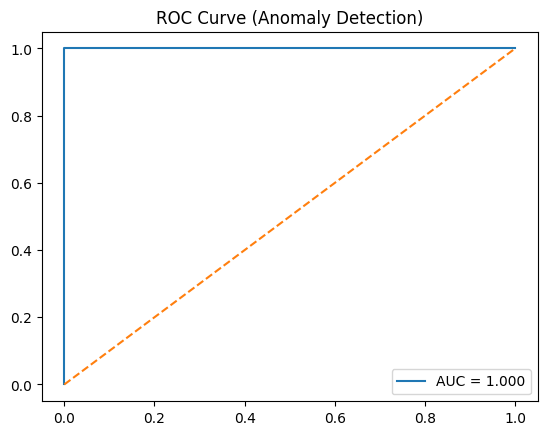

In [22]:
from sklearn.metrics import roc_curve, auc

# decision scores (not probabilities)
scores = model.decision_function(X_test)

# pseudo labels (1 normal, -1 anomaly → convert to 0/1)
y_true = (model.predict(X_test) == 1).astype(int)

fpr, tpr, _ = roc_curve(y_true, scores)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1],[0,1],'--')
plt.title("ROC Curve (Anomaly Detection)")
plt.legend()
plt.show()

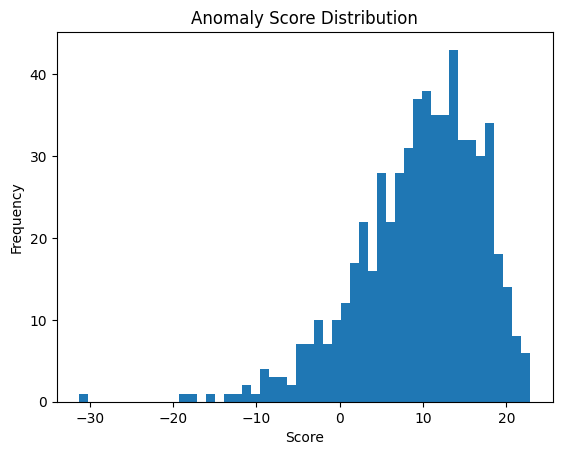

In [23]:
plt.hist(scores, bins=50)
plt.title("Anomaly Score Distribution")
plt.xlabel("Score")
plt.ylabel("Frequency")
plt.show()

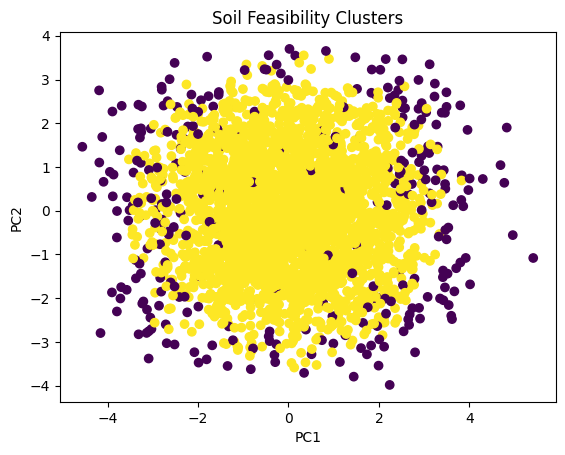

In [24]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(x_scale)

preds = model.predict(x_scale)

plt.scatter(X_pca[:,0], X_pca[:,1], c=preds)
plt.title("Soil Feasibility Clusters")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

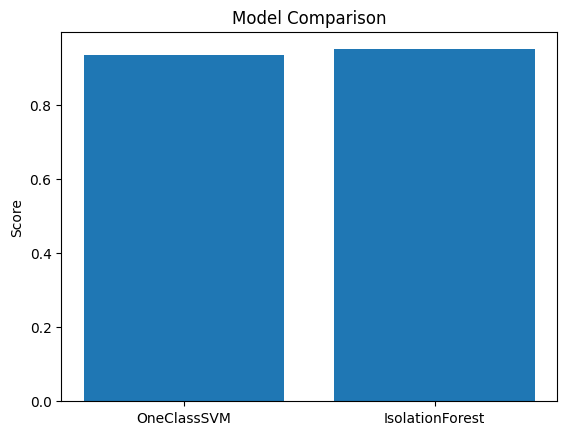

In [25]:
plt.bar(["OneClassSVM", "IsolationForest"], [test_acc, acc_iso])
plt.title("Model Comparison")
plt.ylabel("Score")
plt.show()

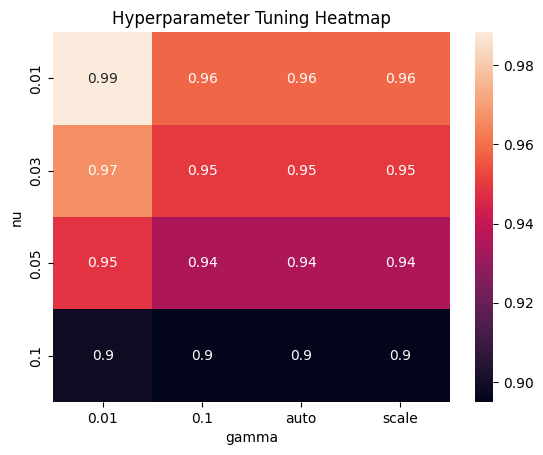

In [26]:
results = []

for nu in [0.01, 0.03, 0.05, 0.1]:
    for gamma in ['scale', 'auto', 0.1, 0.01]:
        model = OneClassSVM(kernel='rbf', nu=nu, gamma=gamma)
        model.fit(X_train)
        preds = model.predict(X_test)
        acc = (preds == 1).mean()
        results.append((nu, gamma, acc))

import pandas as pd
res_df = pd.DataFrame(results, columns=["nu", "gamma", "score"])

pivot = res_df.pivot(index="nu", columns="gamma", values="score")

import seaborn as sns
sns.heatmap(pivot, annot=True)
plt.title("Hyperparameter Tuning Heatmap")
plt.show()